# E337 - Grupo 1 - Trabajo Práctico 2
Integrantes: Constanza María Efkhanian - Julián Fabrizio Notario - María Florencia Pascale

## Bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
!pip install xlrd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import cut_tree
!pip install KModes
from kmodes.kmodes import KModes


## Directorio

In [2]:
directorio = "/Users/lucianaazulramirez/Desktop/Pre-Doc/Big Data/E337_Grupo1/TP2"
os.chdir(directorio)
print(os.getcwd())

/Users/lucianaazulramirez/Desktop/Pre-Doc/Big Data/E337_Grupo1/TP2


## Limpieza de la base de datos

Nuestro objetivo aquí es limpiar y concatenar los dos data frames con todas sus variables. Para este paso, reutilizamos gran parte del código que habíamos escrito en el TP1, pero también hicimos algunos cambios; el código anterior estaba especificado para que solo hubiese 15 variables en el data frame nuevo, y aquí queremos incluir todas. 

In [3]:
# Abrimos las bases de datos
df_2005_raw = pd.read_stata('usu_individual_3105.dta', convert_categoricals=False, convert_missing=False)
df_2005_raw['EMPLEO'] = np.nan # Creamos la variable EMPLEO en la base del 2005 porque no está

df_2025_raw = pd.read_excel('usu_individual_T325.xls')
    
# Pasamos todas las variables a mayúsculas para armonizarlas:
df_2005_raw.columns = df_2005_raw.columns.str.upper().str.strip()
df_2025_raw.columns = df_2025_raw.columns.str.upper().str.strip()

# Filtramos por GBA
df_2005 = df_2005_raw[df_2005_raw['REGION'] == 1].copy()
df_2025 = df_2025_raw[df_2025_raw['REGION'] == 1].copy()

print(f"\nFiltro GBA")
print(f"  2005: {len(df_2005):,} observaciones")
print(f"  2025: {len(df_2025):,} observaciones")

# Ahora, forzamos el año:
df_2005['ANO4'] = 2005
df_2025['ANO4'] = 2025



Filtro GBA
  2005: 9,420 observaciones
  2025: 7,447 observaciones


In [4]:

# AGREGAMOS LA BASE DE HOGARES PARA CONSEGUIR IX_TOT
df_2025 = df_2025.drop(columns=['IX_TOT'], errors='ignore')
df_2005 = df_2005.drop(columns=['IX_TOT'], errors='ignore')

# Normalizamos CODUSU de los individuales para que matcheen con los de hogar
df_2025['CODUSU'] = df_2025['CODUSU'].astype(str).str.strip()
df_2005['CODUSU'] = pd.to_numeric(df_2005['CODUSU'], errors='coerce').astype('Int64').astype(str).str.strip()

hogar_2025 = pd.read_excel('usu_hogar_T325.xlsx')
hogar_2025.columns = hogar_2025.columns.str.upper().str.strip()
hogar_2025 = hogar_2025[hogar_2025['REGION'] == 1][['CODUSU', 'NRO_HOGAR', 'IX_TOT']].copy()
hogar_2025['CODUSU'] = hogar_2025['CODUSU'].astype(str).str.strip()
hogar_2025['NRO_HOGAR'] = pd.to_numeric(hogar_2025['NRO_HOGAR'], errors='coerce')
df_2025 = df_2025.merge(hogar_2025, on=['CODUSU', 'NRO_HOGAR'], how='left')

hogar_2005 = pd.read_stata('Hogar_t305.dta', convert_categoricals=False, convert_missing=False)
hogar_2005.columns = hogar_2005.columns.str.upper().str.strip()
hogar_2005 = hogar_2005[hogar_2005['REGION'] == 1][['CODUSU', 'NRO_HOGAR', 'IX_TOT']].copy()
hogar_2005['CODUSU'] = pd.to_numeric(hogar_2005['CODUSU'], errors='coerce').astype('Int64').astype(str).str.strip()
hogar_2005['NRO_HOGAR'] = pd.to_numeric(hogar_2005['NRO_HOGAR'], errors='coerce')
df_2005 = df_2005.merge(hogar_2005, on=['CODUSU', 'NRO_HOGAR'], how='left')

# Verificamos que matcheen
print("Match 2025:", df_2025['IX_TOT'].notna().sum(), "de", len(df_2025)) 
print("Match 2005:", df_2005['IX_TOT'].notna().sum(), "de", len(df_2005))

Match 2025: 7447 de 7447
Match 2005: 9420 de 9420


Luego, toca convertir las variables categóricas a un mismo formato. Esta parte la hicimos con ayuda de la IA. 

In [5]:
# ARMONIZACIÓN DE FORMATOS

# Variables de ingresos con -9 sin limpiar en 2025 
vars_ingreso_extra = [
    'PP08D1', 'PP08F1', 'PP08F2', 'PP08J1', 'PP08J2', 'PP08J3',
    'TOT_P12', 'P47T', 'T_VI',
    'V3_M', 'V4_M', 'V8_M', 'V9_M', 'V10_M', 'V12_M', 'V18_M'
]

for col in vars_ingreso_extra:
    if col in df_2025.columns:
        df_2025.loc[df_2025[col] == -9, col] = np.nan

print("[1] -9 en variables de ingreso → NaN (2025)")


# PROBLEMA 2: Variables de código string vs float 
def normalizar_codigo(serie):
    """Convierte string o float a string entero limpio. NaN se preserva."""
    def _conv(x):
        if pd.isna(x):
            return np.nan
        try:
            val = str(x).strip()
            if val == '' or val in ('nan', 'None'):
                return np.nan
            return str(int(float(val)))
        except:
            return np.nan
    return serie.apply(_conv)

vars_codigo = [
    'CH14', 'CH15_COD', 'CH16_COD',
    'PP04B_COD', 'PP04D_COD', 'PP11B_COD', 'PP11D_COD'
]

for col in vars_codigo:
    if col in df_2005.columns:
        df_2005[col] = normalizar_codigo(df_2005[col])
    if col in df_2025.columns:
        df_2025[col] = normalizar_codigo(df_2025[col])

print("[2] Variables de código normalizadas a string entero limpio")


#PROBLEMA 3: Variables de deciles con padding inconsistente
vars_deciles = [
    'DECOCUR', 'IDECOCUR', 'RDECOCUR', 'GDECOCUR', 'PDECOCUR', 'ADECOCUR',
    'DECINDR', 'IDECINDR', 'RDECINDR', 'GDECINDR', 'PDECINDR', 'ADECINDR',
    'DECIFR',  'IDECIFR',  'RDECIFR',  'GDECIFR',  'PDECIFR',  'ADECIFR',
    'DECCFR',  'IDECCFR',  'RDECCFR',  'GDECCFR',  'PDECCFR',  'ADECCFR'
]

for col in vars_deciles:
    if col in df_2005.columns:
        df_2005[col] = normalizar_codigo(df_2005[col])
    if col in df_2025.columns:
        df_2025[col] = normalizar_codigo(df_2025[col])

print("[3] Variables de deciles normalizadas")


#   VERIFICACIÓN 
print("\nVerificación post-armonización:")
for col in ['CH14', 'DECOCUR', 'PP04B_COD']:
    v05 = set(df_2005[col].dropna().unique()) if col in df_2005.columns else set()
    v25 = set(df_2025[col].dropna().unique()) if col in df_2025.columns else set()
    comunes = v05 & v25
    print(f"  {col}: {len(comunes)} valores en común entre bases")

[1] -9 en variables de ingreso → NaN (2025)
[2] Variables de código normalizadas a string entero limpio
[3] Variables de deciles normalizadas

Verificación post-armonización:
  CH14: 12 valores en común entre bases
  DECOCUR: 11 valores en común entre bases
  PP04B_COD: 29 valores en común entre bases


Ahora toca eliminar los valores sin sentido de la base de datos. Para esto, utilizamos ayuda de Claude. Le enviamos los diccionarios de ambos años y le pedimos que identificara potenciales valores sin sentido. A continuación, le pedimos un código que reemplazara los valores sin sentido por valores NaN. El chat completo de esta sección y demás chats en los que hayamos interactuado con la IA pueden hallarse en la parte III del informe. 

In [6]:
# --- Corrección de columnas con tipos mixtos ---

# CODUSU: código de hogar, es numérico
df_2005['CODUSU'] = pd.to_numeric(df_2005['CODUSU'], errors='coerce').astype('Int64').astype(str).str.strip()
df_2025['CODUSU'] = df_2025['CODUSU'].astype(str).str.strip()

# PP09C_ESP: texto libre, se unifica como string (vacío si no hay dato)
df_2005['PP09C_ESP'] = df_2005['PP09C_ESP'].fillna('').astype(str).str.strip()
df_2025['PP09C_ESP'] = df_2025['PP09C_ESP'].fillna('').astype(str).str.strip()

# CH05: fecha de nacimiento, se unifica como string en formato dd/mm/yyyy
# CH05: fecha de nacimiento, se unifica como string en formato dd/mm/yyyy
# (puede no existir en todas las bases)
for df_temp in [df_2005, df_2025]:
    if 'CH05' in df_temp.columns:
        df_temp['CH05'] = df_temp['CH05'].astype(str).str.strip().replace('nan', np.nan)

# -----------------------------------------------------

# --- CH06: edad inválida ---
df_2005['CH06'] = df_2005['CH06'].replace(-1, np.nan)
df_2025['CH06'] = df_2025['CH06'].replace(-1, np.nan)

# --- CH07: estado civil Ns/Nr ---
df_2005['CH07'] = df_2005['CH07'].replace(9, np.nan)
df_2025['CH07'] = df_2025['CH07'].replace(9, np.nan)

# --- CH08: cobertura médica Ns/Nr ---
df_2005['CH08'] = df_2005['CH08'].replace(9, np.nan)
df_2025['CH08'] = df_2025['CH08'].replace(9, np.nan)

# --- CH14: Ns/Nr ---
df_2005['CH14'] = df_2005['CH14'].replace(99, np.nan)
df_2025['CH14'] = df_2025['CH14'].replace(99, np.nan)

# --- PP3E_TOT y PP3F_TOT: horas trabajadas, 999 = Ns/Nr ---
df_2005['PP3E_TOT'] = pd.to_numeric(df_2005['PP3E_TOT'], errors='coerce').replace(999, np.nan)
df_2025['PP3E_TOT'] = pd.to_numeric(df_2025['PP3E_TOT'], errors='coerce').replace(999, np.nan)
df_2005['PP3F_TOT'] = pd.to_numeric(df_2005['PP3F_TOT'], errors='coerce').replace(999, np.nan)
df_2025['PP3F_TOT'] = pd.to_numeric(df_2025['PP3F_TOT'], errors='coerce').replace(999, np.nan)

# --- NIVEL_ED: nivel educativo Ns/Nr ---
df_2005['NIVEL_ED'] = df_2005['NIVEL_ED'].replace(9, np.nan)
df_2025['NIVEL_ED'] = df_2025['NIVEL_ED'].replace(9, np.nan)

# --- CAT_OCUP: categoría ocupacional Ns/Nr ---
df_2005['CAT_OCUP'] = df_2005['CAT_OCUP'].replace(9, np.nan)
df_2025['CAT_OCUP'] = df_2025['CAT_OCUP'].replace(9, np.nan)

# --- PP04A: tipo de empresa ---
df_2005['PP04A'] = df_2005['PP04A'].replace({0: np.nan, 9: np.nan})
df_2025['PP04A'] = df_2025['PP04A'].replace({0: np.nan, 9: np.nan})

# --- P21: ingreso ocupación principal ---
df_2005.loc[df_2005['P21'] < 0, 'P21'] = np.nan
df_2025.loc[df_2025['P21'] < 0, 'P21'] = np.nan

# --- IPCF: ingreso per cápita familiar ---
df_2005.loc[df_2005['IPCF'] < 0, 'IPCF'] = np.nan
df_2025.loc[df_2025['IPCF'] < 0, 'IPCF'] = np.nan

# --- PP06C y PP06D: ingresos de independientes ---
for col in ['PP06C', 'PP06D']:
    for df_temp in [df_2005, df_2025]:
        if col in df_temp.columns:
            df_temp[col] = df_temp[col].replace({-7: np.nan, -8: np.nan, -9: np.nan})

# --- EMPLEO ---
if 'EMPLEO' in df_2025.columns:
    df_2025['EMPLEO'] = df_2025['EMPLEO'].replace(9, np.nan)

# --- PP3E_TOT y PP3F_TOT: horas trabajadas, 999 = Ns/Nr ---
df_2005['PP3E_TOT'] = pd.to_numeric(df_2005['PP3E_TOT'], errors='coerce').replace(999, np.nan)
df_2025['PP3E_TOT'] = pd.to_numeric(df_2025['PP3E_TOT'], errors='coerce').replace(999, np.nan)
df_2005['PP3F_TOT'] = pd.to_numeric(df_2005['PP3F_TOT'], errors='coerce').replace(999, np.nan)
df_2025['PP3F_TOT'] = pd.to_numeric(df_2025['PP3F_TOT'], errors='coerce').replace(999, np.nan)


El siguiente código lo agregamos debido a que habían ciertas inconsistencias entre las dos bases de la EPH. Para esto, utilizamos ayuda de la inteligencia artificial, específicamente de Claude.

In [7]:
# 
# ARMONIZACIÓN DE CODIFICACIÓN ENTRE 2005 Y 2025

#INTENSI: recodificar 2005 al esquema de 2025 
# 2005: 1=SubocDemandante, 2=SubocNoDemandante, 3=OcupPleno, 4=Sobreocupado, 5=NoTrabajó, 9=Ns/Nr
# 2025: 1=Subocupado,      2=OcupPleno,         3=Sobreocupado, 4=NoTrabajó,    9=Ns/Nr
# Se fusionan las categorías 1 y 2 de 2005 (ambas subocupación) en la categoría 1 de 2025.
intensi_map_2005 = {
    1: 1,   # Subocupado demandante → Subocupado
    2: 1,   # Subocupado no demandante → Subocupado
    3: 2,   # Ocupado pleno → Ocupado pleno
    4: 3,   # Sobreocupado → Sobreocupado
    5: 4,   # No trabajó en la semana → No trabajó en la semana
    9: 9,   # Ns/Nr → Ns/Nr
    0: 0    # No corresponde → No corresponde
}
df_2005['INTENSI'] = df_2005['INTENSI'].map(intensi_map_2005)
print("[4] INTENSI recodificado de 2005 al esquema 2025")


# --- PP04G: recodificar 2005 al esquema de 2025 ---
# En 2005, código 1 = "local/oficina/establecimiento/negocio/taller/chacra/finca" (todo junto).
# En 2025, se desagregó en: 11=local/oficina/taller, 12=vivienda con lugar exclusivo, 13=chacra/finca.
# Como no es posible desagregar el viejo código 1, se mapea a 11 (la subcategoría más común en GBA).
# Los demás códigos (2-10) son idénticos.
df_2005.loc[df_2005['PP04G'] == 1, 'PP04G'] = 11
print("[5] PP04G código 1 (2005) → 11 (esquema 2025)")


# --- PP07E: en 2005 existía 1="plan de empleo", eliminado en 2025 ---
# En 2025 solo existen 2=período de prueba, 3=beca/pasantía, 4=ninguno.
# Opciones: (a) dejar el 1 como está (categoría exclusiva de 2005),
#           (b) recodificarlo a NaN.
# Elegimos (a) para no perder información; pero si se necesita comparabilidad estricta, usar (b).
# Descomentar la línea siguiente para opción (b):
# df_2005.loc[df_2005['PP07E'] == 1, 'PP07E'] = np.nan
print("[6] PP07E: código 1 (plan de empleo) solo existe en 2005 — sin cambio")


# --- PP11M: en 2005 existía 1="plan de empleo", eliminado en 2025 ---
# Misma situación que PP07E.
# Descomentar para convertir a NaN si se desea comparabilidad estricta:
# df_2005.loc[df_2005['PP11M'] == 1, 'PP11M'] = np.nan
print("[7] PP11M: código 1 (plan de empleo) solo existe en 2005 — sin cambio")


# --- PP11L1: pregunta diferente entre años ---
# 2005: "¿Ese trabajo era... 1=changa/transitorio, 2=permanente, 3=Ns/Nr?"
# 2025: "¿Cobraba algún plan? 1=Sí, 2=No"
# NO SON COMPARABLES. Se recodifica 2005 a NaN para evitar confusión.
df_2005['PP11L1'] = np.nan
print("[8] PP11L1: pregunta incompatible entre años → NaN en 2005")


# --- Verificación final ---
print("\nVerificación post-armonización de codificación:")
for col in ['INTENSI', 'PP04G']:
    v05 = set(df_2005[col].dropna().unique())
    v25 = set(df_2025[col].dropna().unique())
    print(f"  {col}:")
    print(f"    2005 (recodificado): {sorted(v05)}")
    print(f"    2025:                {sorted(v25)}")

[4] INTENSI recodificado de 2005 al esquema 2025
[5] PP04G código 1 (2005) → 11 (esquema 2025)
[6] PP07E: código 1 (plan de empleo) solo existe en 2005 — sin cambio
[7] PP11M: código 1 (plan de empleo) solo existe en 2005 — sin cambio
[8] PP11L1: pregunta incompatible entre años → NaN en 2005

Verificación post-armonización de codificación:
  INTENSI:
    2005 (recodificado): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(9)]
    2025:                [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  PP04G:
    2005 (recodificado): [np.float64(0.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(99.0)]
    2025:                [np.float64(0.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float6

In [8]:
# Concatenamos los dataframes
df_final = pd.concat([df_2005, df_2025], ignore_index=True)

# Finalmente, guardamos la base df_final combinada como csv. 

df_final.to_csv('eph_gba_merged_full.csv', index=False)
print("\nBase guardada como 'eph_gba_merged_full.csv'")



Base guardada como 'eph_gba_merged_full.csv'


### Ejercicio 1


In [8]:
# Abrimos el csv. 
df_eph_GBA = pd.read_csv('eph_gba_merged_full.csv', dtype={
    # Identificadores
    'CODUSU':     'object',
    'PP09C_ESP':  'object',
    'CH05':       'object',
    # Columnas de códigos normalizados a string por normalizar_codigo()
    'CH14':       'object',
    'CH15_COD':   'object',
    'CH16_COD':   'object',
    'PP04B_COD':  'object',
    'PP04D_COD':  'object',
    'PP11B_COD':  'object',
    'PP11D_COD':  'object',
    # Columnas de deciles
    'DECOCUR':    'object',
    'IDECOCUR':   'object',
    'RDECOCUR':   'object',
    'GDECOCUR':   'object',
    'PDECOCUR':   'object',
    'ADECOCUR':   'object',
    'IDECINDR':   'object',
    'PDECINDR':   'object',
    'IDECIFR':    'object',
    'PDECIFR':    'object',
    'IDECCFR':    'object',
    'PDECCFR':    'object',
})

df_eph_GBA = df_eph_GBA.copy() # Desfragmenta

In [9]:
df_eph_GBA["edad2"] = (df_eph_GBA["CH06"])**2

In [10]:
# Para esta parte, reutilizaremos el código del TP1. 

norespondieron = df_eph_GBA [df_eph_GBA['ESTADO'] == 0].copy()
respondieron   =df_eph_GBA [df_eph_GBA['ESTADO'] != 0].copy()

print("No respondieron (ESTADO = 0):", len(norespondieron))
print("Respondieron    (ESTADO ≠ 0):", len(respondieron))

ocupados = respondieron[respondieron['ESTADO'] == 1].copy()

print("Ocupados (ESTADO = 1):", len(ocupados))

ocupados['informal'] = 0

ocupados.loc[(ocupados['CAT_OCUP'] == 3) & (ocupados['PP07H'] == 2), 'informal'] = 1
ocupados.loc[ocupados['CAT_OCUP'] == 4, 'informal'] = 1

print("Formales  (informal = 0):", (ocupados['informal'] == 0).sum())
print("Informales (informal = 1):", (ocupados['informal'] == 1).sum())
print("Tasa de informalidad:", round((ocupados['informal'] == 1).sum() / len(ocupados) * 100, 1), "%")

No respondieron (ESTADO = 0): 24
Respondieron    (ESTADO ≠ 0): 16843
Ocupados (ESTADO = 1): 7625
Formales  (informal = 0): 5288
Informales (informal = 1): 2337
Tasa de informalidad: 30.6 %


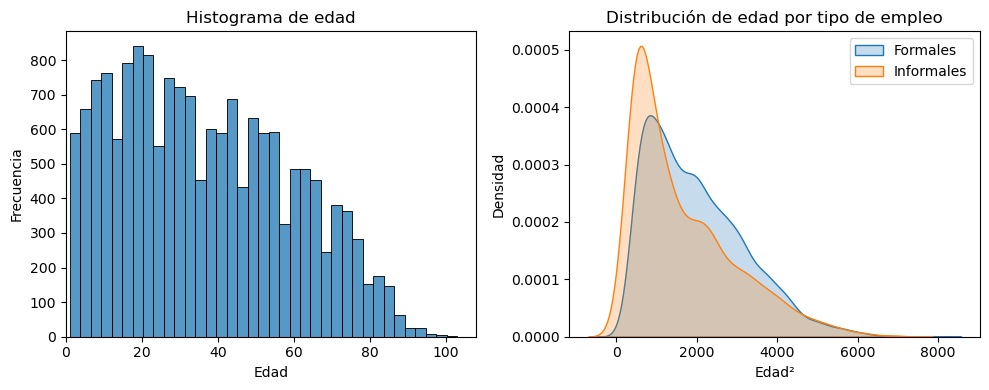

In [11]:
# Ahora, realizaremos el histograma  de la variable edad en un panel A, y la distribución de kernels para los trabajadores formales e informales en un panel B.

data_edad = df_eph_GBA["CH06"]
data_edad2 = df_eph_GBA["edad2"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(data_edad, ax=axes[0])
axes[0].set_xlim(left=0)
axes[0].set_title("Histograma de edad")


axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(left=0)


axes[1].set_title("Densidad de Kernel (KDE)")
formales = ocupados [ocupados["informal"] == 0]["edad2"]
informales = ocupados [ocupados["informal"] == 1]["edad2"]
sns.kdeplot(formales,   fill=True, label="Formales",   ax=axes[1])
sns.kdeplot(informales, fill=True, label="Informales", ax=axes[1])

axes[1].set_xlabel("Edad²")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Distribución de edad por tipo de empleo")
axes[1].legend()


plt.tight_layout()
plt.savefig('Histograma y DistKernel.png', bbox_inches='tight', dpi=300)
plt.show()



### Ejercicio 2

In [12]:
# El objetivo es crear la variable "educ".

# Primero, convertimos las variables a valores numéricos:
df_eph_GBA['CH12'] = pd.to_numeric(df_eph_GBA['CH12'], errors='coerce')
df_eph_GBA['CH13'] = pd.to_numeric(df_eph_GBA['CH13'], errors='coerce')
df_eph_GBA['CH14'] = pd.to_numeric(df_eph_GBA['CH14'], errors='coerce')

# Creamos "educ" según si se finalizó o no el nivel:
df_eph_GBA['educ'] = np.nan

# Si el individuo finalizó (CH13 == 1): años totales del nivel
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 1) & (df_eph_GBA['CH13'] == 1), 'educ'] = 0
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 2) & (df_eph_GBA['CH13'] == 1), 'educ'] = 6
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 3) & (df_eph_GBA['CH13'] == 1), 'educ'] = 9
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 4) & (df_eph_GBA['CH13'] == 1), 'educ'] = 12
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 5) & (df_eph_GBA['CH13'] == 1), 'educ'] = 12
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 6) & (df_eph_GBA['CH13'] == 1), 'educ'] = 15
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 7) & (df_eph_GBA['CH13'] == 1), 'educ'] = 17
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 8) & (df_eph_GBA['CH13'] == 1), 'educ'] = 20

# Si el individuo no finalizó (CH13 == 2): base del nivel + años cursados (CH14)
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 1) & (df_eph_GBA['CH13'] == 2), 'educ'] = 0  + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 2) & (df_eph_GBA['CH13'] == 2), 'educ'] = 0  + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 3) & (df_eph_GBA['CH13'] == 2), 'educ'] = 0  + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 4) & (df_eph_GBA['CH13'] == 2), 'educ'] = 6  + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 5) & (df_eph_GBA['CH13'] == 2), 'educ'] = 6  + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 6) & (df_eph_GBA['CH13'] == 2), 'educ'] = 12 + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 7) & (df_eph_GBA['CH13'] == 2), 'educ'] = 12 + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 8) & (df_eph_GBA['CH13'] == 2), 'educ'] = 17 + df_eph_GBA['CH14']


# Estadística descriptiva
print(df_eph_GBA['educ'].agg(['mean', 'std', 'min', 'median', 'max']).round(2))

mean       10.61
std        12.31
min         0.00
median      9.00
max       116.00
Name: educ, dtype: float64


### Ejercicio 3

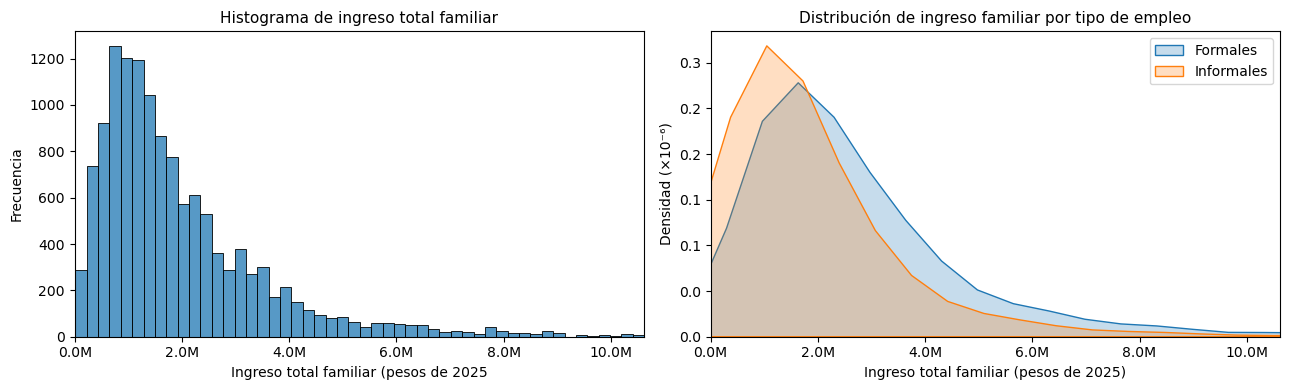

mean      2.112352e+06
std       3.191931e+06
min       1.000000e+04
median    1.500000e+06
max       1.296000e+08
Name: ingreso_total_familiar, dtype: float64


In [13]:
# Para actualizar la variable ingreso_total_familiar, necesitamos actualizar el valor de inflación.
# Como la inflación acumulada de Argentina entre 2005 y 2025 fue de aproximadamente 120.000 %, 
## vamos a deflactar según ese valor. 

factor = 1200

df_eph_GBA['ingreso_total_familiar'] = np.where(
    df_eph_GBA['ANO4'] == 2005,
    df_eph_GBA['ITF'] * factor,
    df_eph_GBA['ITF']
)
df_eph_GBA.loc[df_eph_GBA['ingreso_total_familiar'] <= 0, 'ingreso_total_familiar'] = np.nan

limite = df_eph_GBA['ingreso_total_familiar'].quantile(0.99)

ocupados['ingreso_total_familiar'] = np.where(
    ocupados['ANO4'] == 2005,
    ocupados['ITF'] * factor,
    ocupados['ITF']
)
ocupados.loc[ocupados['ingreso_total_familiar'] <= 0, 'ingreso_total_familiar'] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

fmt_millones = mpl.ticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')

#Histograma
datos_hist = df_eph_GBA['ingreso_total_familiar'].dropna()
datos_hist = datos_hist[datos_hist <= limite]

sns.histplot(datos_hist, ax=axes[0], bins=50)
axes[0].set_title("Histograma de ingreso total familiar", fontsize=11)
axes[0].set_xlabel("Ingreso total familiar (pesos de 2025")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(0, limite)
axes[0].xaxis.set_major_formatter(fmt_millones)

#Kernel
formales   = ocupados[ocupados['informal'] == 0]['ingreso_total_familiar'].dropna()
informales = ocupados[ocupados['informal'] == 1]['ingreso_total_familiar'].dropna()

sns.kdeplot(formales,   fill=True, label='Formales',   ax=axes[1])
sns.kdeplot(informales, fill=True, label='Informales', ax=axes[1])
axes[1].set_title("Distribución de ingreso familiar por tipo de empleo", fontsize=11)
axes[1].set_xlabel("Ingreso total familiar (pesos de 2025)")
axes[1].set_ylabel("Densidad (×10⁻⁶)")
axes[1].set_xlim(0, limite)
axes[1].xaxis.set_major_formatter(fmt_millones)
axes[1].yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda y, _: f'{y*1_000_000:.1f}')
)
axes[1].legend()

plt.tight_layout()
plt.savefig('Histograma_Ingresos_y_DistKernel.png', bbox_inches='tight', dpi=300)
plt.show()

print(df_eph_GBA['ingreso_total_familiar'].agg(['mean', 'std', 'min', 'median', 'max']).round(2))

### Ejercicio 4

In [14]:
# El objetivo es crear la variable horastrab como el total de horas trabajadas como la suma de las horas en la ocupación
## principal y otras ocupaciones.

jefes = df_eph_GBA[df_eph_GBA['CH03'] == 1].copy()
jefes['horastrab'] = jefes['PP3E_TOT'] + jefes['PP3F_TOT']
df_eph_GBA['horastrab'] = df_eph_GBA['PP3E_TOT'] + df_eph_GBA['PP3F_TOT']
print(jefes['horastrab'].agg(['mean', 'std', 'min', 'median', 'max']).round(2))


mean       33.75
std        24.10
min         0.00
median     40.00
max       122.00
Name: horastrab, dtype: float64


### Ejercicio 5

In [16]:
# Informal: la variable vive en 'ocupados', la pegamos a df_eph_GBA
df_eph_GBA['informal'] = np.nan
df_eph_GBA.loc[ocupados.index, 'informal'] = ocupados['informal']

# Separamos df_eph_GBA por año
df_2005_final = df_eph_GBA[df_eph_GBA['ANO4'] == 2005]
df_2025_final = df_eph_GBA[df_eph_GBA['ANO4'] == 2025]

# Cantidad de observaciones
obs_2005  = len(df_2005_final)
obs_2025  = len(df_2025_final)
obs_total = len(df_eph_GBA)

# NaNs en informal por año
na_inf_2005  = df_2005_final['informal'].isna().sum()
na_inf_2025  = df_2025_final['informal'].isna().sum()
na_inf_total = df_eph_GBA['informal'].isna().sum()

# Informales por año
inf_2005  = (df_2005_final['informal'] == 1).sum()
inf_2025  = (df_2025_final['informal'] == 1).sum()
inf_total = (df_eph_GBA['informal'] == 1).sum()

# Formales por año
for_2005  = (df_2005_final['informal'] == 0).sum()
for_2025  = (df_2025_final['informal'] == 0).sum()
for_total = (df_eph_GBA['informal'] == 0).sum()

# Cantidad de variables limpias y homogeneizadas
vars_limpias = len(df_eph_GBA.columns)

# Imprimimos tabla
print(f"{'':45} {'2005':>8} {'2025':>8} {'Total':>8}")
print("-" * 71)
print(f"{'Cantidad de observaciones':45} {obs_2005:>8} {obs_2025:>8} {obs_total:>8}")
print(f"{'Obs. con NAs en Informal':45} {na_inf_2005:>8} {na_inf_2025:>8} {na_inf_total:>8}")
print(f"{'Cantidad de Informales':45} {inf_2005:>8} {inf_2025:>8} {inf_total:>8}")
print(f"{'Cantidad de Formales':45} {for_2005:>8} {for_2025:>8} {for_total:>8}")
print(f"{'Cantidad de variables limpias y homogeneizadas':45} {vars_limpias:>8} {vars_limpias:>8} {vars_limpias:>8}")

                                                  2005     2025    Total
-----------------------------------------------------------------------
Cantidad de observaciones                         9420     7447    16867
Obs. con NAs en Informal                          5332     3910     9242
Cantidad de Informales                            1412      925     2337
Cantidad de Formales                              2676     2612     5288
Cantidad de variables limpias y homogeneizadas      249      249      249


# Parte II: Métodos No Supervisados

### Ejercicio 1

In [17]:
vars_corr = {
    'CH06': 'Edad',
    'edad2': 'Edad2',
    'educ': 'Años de Educación',
    'ingreso_total_familiar': 'ITF',
    'IX_TOT': 'Personas en el Hogar',
    'horastrab': 'Horas trabajadas',
}

df_corr = (df_eph_GBA[list(vars_corr.keys())].rename(columns=vars_corr).apply(pd.to_numeric, errors = 'coerce'))

corr = df_corr.corr(method='pearson')
print(corr.round(2))



                      Edad  Edad2  Años de Educación   ITF  \
Edad                  1.00   0.96               0.13 -0.02   
Edad2                 0.96   1.00               0.08 -0.04   
Años de Educación     0.13   0.08               1.00  0.08   
ITF                  -0.02  -0.04               0.08  1.00   
Personas en el Hogar -0.41  -0.40              -0.10  0.06   
Horas trabajadas      0.18   0.04               0.17  0.09   

                      Personas en el Hogar  Horas trabajadas  
Edad                                 -0.41              0.18  
Edad2                                -0.40              0.04  
Años de Educación                    -0.10              0.17  
ITF                                   0.06              0.09  
Personas en el Hogar                  1.00             -0.13  
Horas trabajadas                     -0.13              1.00  


## PCA

### Ejercicio 2
Aplicamos PCA a las seis variables seleccionadas previamente. Estandarizamos y luego hacemos un gráfico de dispersión mostrando los scores calculados para el primer y segundo componente de PCA.

Observaciones del PCA 10495
Edad                   -0.0
Edad2                   0.0
Años de Educación      -0.0
ITF                    -0.0
Personas en el Hogar    0.0
Horas trabajadas       -0.0
dtype: float64
Edad                    1.0
Edad2                   1.0
Años de Educación       1.0
ITF                     1.0
Personas en el Hogar    1.0
Horas trabajadas        1.0
dtype: float64
Varianza por componente:
  CP1: 37.5%
  CP2: 20.8%
  CP3: 15.8%
  CP4: 13.6%
  CP5: 11.9%
  CP6: 0.4%

Varianza acumulada CP1+CP2: 58.3%


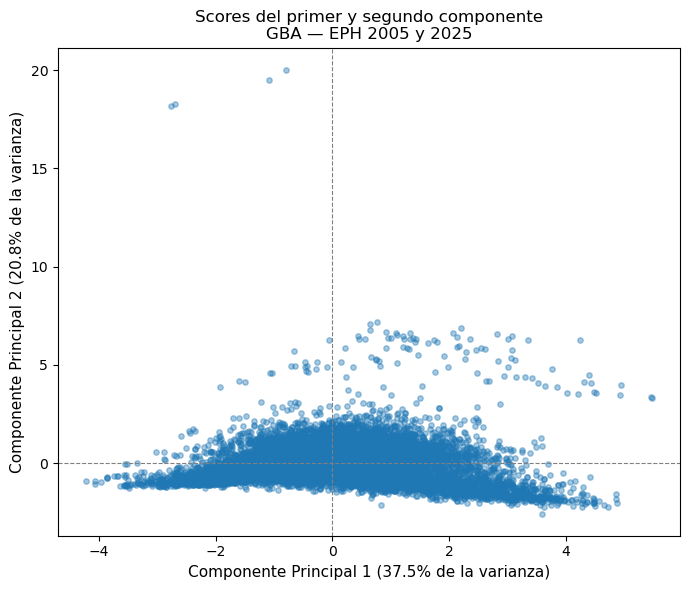

In [18]:
#Seleccionamos variables

vars_pca = {
    'CH06': 'Edad',
    'edad2': 'Edad2',
    'educ': 'Años de Educación',
    'ingreso_total_familiar': 'ITF',
    'IX_TOT': 'Personas en el Hogar',
    'horastrab': 'Horas trabajadas',
}

df_pca = (df_eph_GBA[list(vars_pca.keys())].rename(columns=vars_pca).apply(pd.to_numeric, errors='coerce').dropna())
print("Observaciones del PCA", len(df_pca))

#Estandarizamos
scaler = StandardScaler(with_mean=True, with_std=True)
df_pca_std= pd.DataFrame(scaler.fit_transform(df_pca), columns=df_pca.columns)

print(df_pca_std.mean().round(4)) # Debería ser casi 0
print(df_pca_std.std().round(4)) # Debería ser casi 1


#PCA

pca = PCA()
scores = pca.fit_transform(df_pca_std)

print("Varianza por componente:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  CP{i+1}: {v*100:.1f}%")
print(f"\nVarianza acumulada CP1+CP2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

# Grafico
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(scores[:, 0], scores[:, 1], alpha=0.4, s=15)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

ax.set_xlabel(f'Componente Principal 1 ({var1:.1f}% de la varianza)', fontsize=11)
ax.set_ylabel(f'Componente Principal 2 ({var2:.1f}% de la varianza)', fontsize=11)
ax.set_title('Scores del primer y segundo componente\nGBA — EPH 2005 y 2025', fontsize=12)

plt.tight_layout()
plt.savefig('pca_scores.png', dpi=300, bbox_inches='tight')
plt.show()

### Ejercicio 3
Graficamos con flechas ponderadoras de PCA para primer y segundo componentes.

                        CP1    CP2
Edad                  0.636 -0.097
Edad2                 0.619 -0.204
Años de Educación     0.153  0.582
ITF                  -0.018  0.487
Personas en el Hogar -0.412 -0.063
Horas trabajadas      0.135  0.607


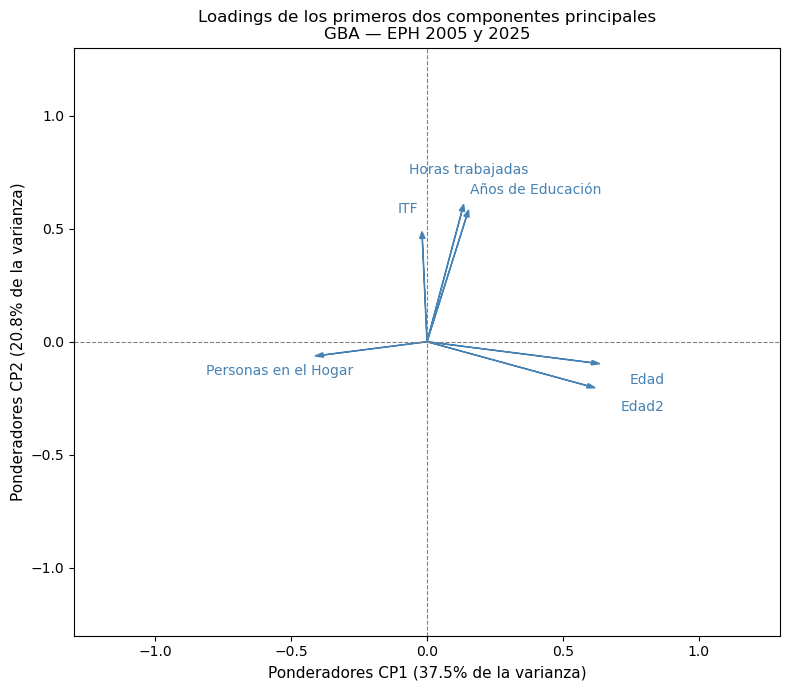

In [19]:
# Tabla Loadings
loadings_df = pd.DataFrame(
    pca.components_[:2].T,
    index=df_pca.columns,
    columns=['CP1', 'CP2']
).round(3)
print(loadings_df)

# Grafico loadings
fig, ax = plt.subplots(figsize=(8, 7))
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

for k, nombre in enumerate(df_pca.columns):
    x = pca.components_[0, k]
    y = pca.components_[1, k]

    ax.arrow(
        0, 0, x, y,
        color='steelblue',
        head_width=0.02,
        length_includes_head=True
    )

    # Cambiamos las ubicaciones de las labels de las flechas dentro del gráfico para que no se superpongan, 
    # tanto entre si como con las flechas. Esto se hizo después de haber creado una vez el gráfico sin los offsets.
    offsets = {
        'Edad':                 ( 0.10, -0.06),
        'Edad2':                ( 0.10, -0.06),
        'Años de Educación':    ( 0.23,  0.02),
        'ITF':                  (-0.05,  0.04),
        'Personas en el Hogar': (-0.08, -0.06),
        'Horas trabajadas':     ( 0.001,  0.08),
    }

    dx, dy = offsets.get(nombre, (0.08, 0.06))

    ax.text(x * 1.12 + dx, y * 1.12 + dy, nombre, fontsize=10, color='steelblue', ha='center', va='center')



ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel(f'Ponderadores CP1 ({var1:.1f}% de la varianza)', fontsize=11)
ax.set_ylabel(f'Ponderadores CP2 ({var2:.1f}% de la varianza)', fontsize=11)
ax.set_title('Loadings de los primeros dos componentes principales\nGBA — EPH 2005 y 2025', fontsize=12)
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

### Ejercicio 4

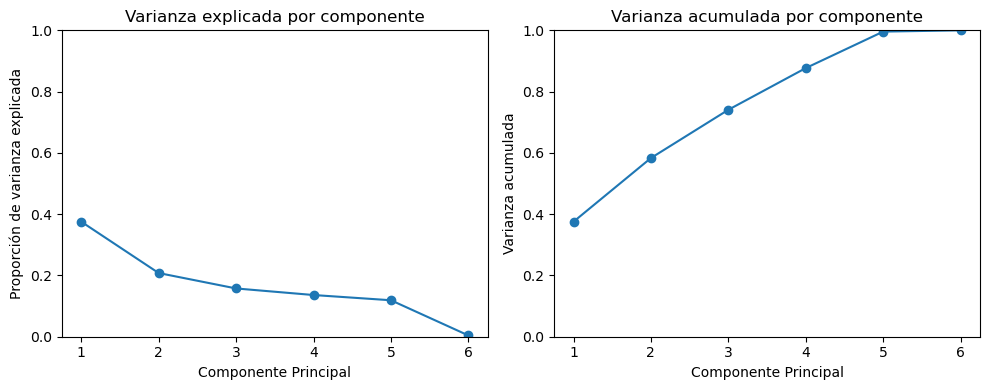

Varianza explicada por componente:
  CP1: 37.5%  (acumulada: 37.5%)
  CP2: 20.8%  (acumulada: 58.3%)
  CP3: 15.8%  (acumulada: 74.1%)
  CP4: 13.6%  (acumulada: 87.7%)
  CP5: 11.9%  (acumulada: 99.6%)
  CP6: 0.4%  (acumulada: 100.0%)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ticks = np.arange(pca.n_components_) + 1

# varianza por componente 
axes[0].plot(ticks, pca.explained_variance_ratio_, marker='o')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Proporción de varianza explicada')
axes[0].set_title('Varianza explicada por componente')
axes[0].set_ylim(0, 1)
axes[0].set_xticks(ticks)

# varianza acumulada 
axes[1].plot(ticks, pca.explained_variance_ratio_.cumsum(), marker='o')
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('Varianza acumulada')
axes[1].set_title('Varianza acumulada por componente')
axes[1].set_ylim(0, 1)
axes[1].set_xticks(ticks)

plt.tight_layout()
plt.savefig('pca_scree.png', dpi=300, bbox_inches='tight')
plt.show()

# Tabla con num exactos para comentar 
print("Varianza explicada por componente:")
acum = 0
for i, v in enumerate(pca.explained_variance_ratio_):
    acum += v
    print(f"  CP{i+1}: {v*100:.1f}%  (acumulada: {acum*100:.1f}%)")

## Cluster

### Ejercicio 5

#### Inciso a

Observaciones para clustering: 5873


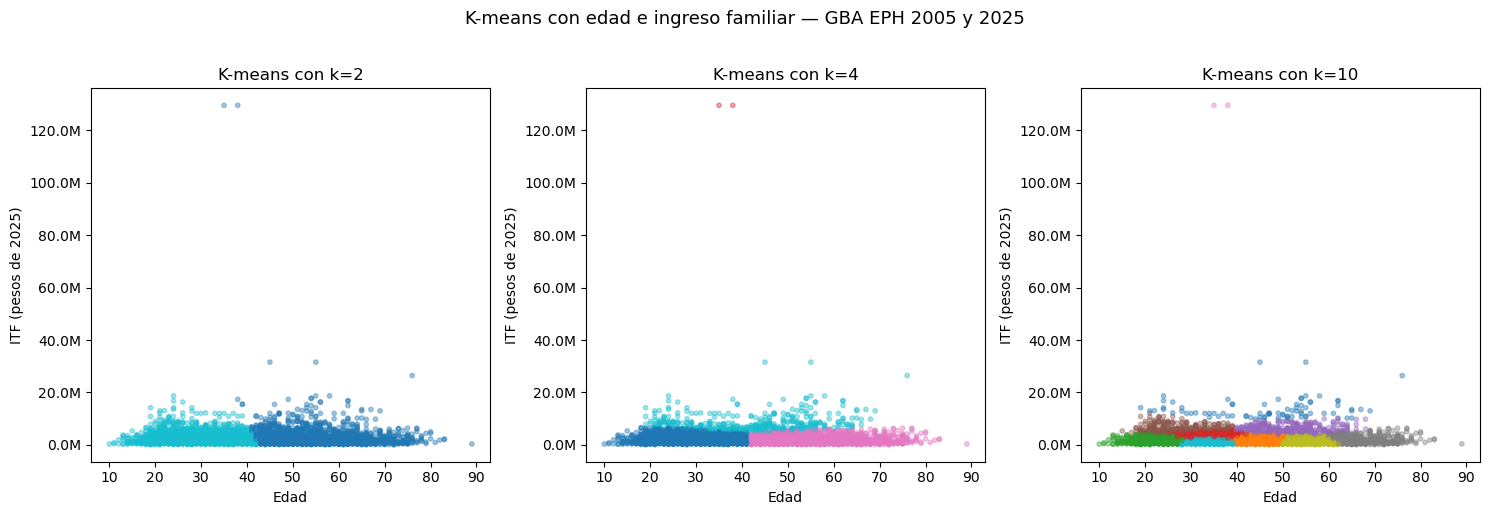


Crosstab cluster k=2 vs formal/informal:
Informal (0=Formal, 1=Informal)   0.0   1.0   All
Cluster                                          
0                                1959   699  2658
1                                2077  1138  3215
All                              4036  1837  5873


In [21]:

# Datos: edad e ITF, solo ocupados con informal definido

df_kmeans = (
    df_eph_GBA[['CH06', 'ingreso_total_familiar', 'informal']]
    .rename(columns={'CH06': 'Edad', 'ingreso_total_familiar': 'ITF'})
    .apply(lambda col: pd.to_numeric(col, errors='coerce'))
    .dropna()
)

print(f"Observaciones para clustering: {len(df_kmeans)}")


#Estandariza solo las features (sin informal) 
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(df_kmeans[['Edad', 'ITF']])


# K-means con k=2, k=4, k=10 
ks = [2, 4, 10]
modelos = {}
for k in ks:
    modelos[k] = KMeans(n_clusters=k, random_state=10, init='random', n_init=20).fit(X_km)


# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, k in zip(axes, ks):
    ax.scatter(
        df_kmeans['Edad'],
        df_kmeans['ITF'] / 1_000_000,
        c=modelos[k].labels_,
        cmap='tab10',
        alpha=0.4,
        s=10
    )
    ax.set_title(f'K-means con k={k}', fontsize=12)
    ax.set_xlabel('Edad')
    ax.set_ylabel('ITF (pesos de 2025)')
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

plt.suptitle('K-means con edad e ingreso familiar — GBA EPH 2005 y 2025', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('kmeans_edad_itf.png', dpi=300, bbox_inches='tight')
plt.show()

# K=2 separa formales e informales? 
df_kmeans['cluster_k2'] = modelos[2].labels_

print("\nCrosstab cluster k=2 vs formal/informal:")
print(pd.crosstab(
    df_kmeans['cluster_k2'],
    df_kmeans['informal'],
    rownames=['Cluster'],
    colnames=['Informal (0=Formal, 1=Informal)'],
    margins=True
))

#### Inciso b - Elbow


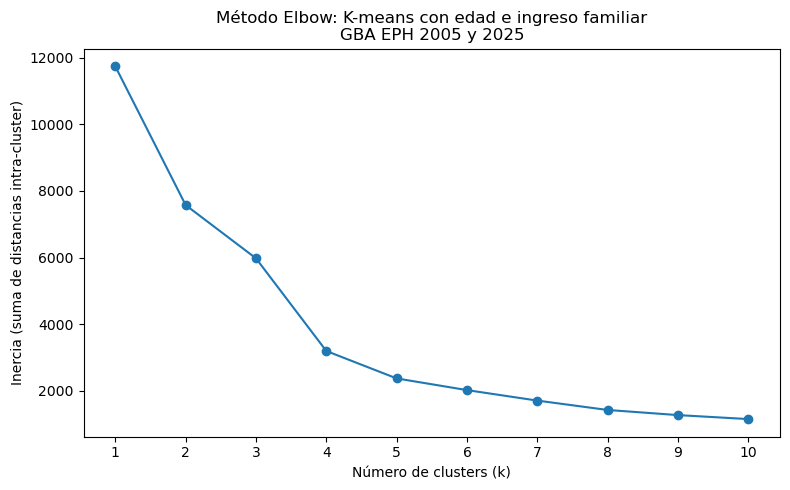

Inercia por número de clusters:
  k= 1: 11,746.0
  k= 2: 7,576.9
  k= 3: 5,975.0
  k= 4: 3,189.7
  k= 5: 2,365.5
  k= 6: 2,014.3
  k= 7: 1,698.8
  k= 8: 1,416.9
  k= 9: 1,263.0
  k=10: 1,143.1


In [22]:
# Elbow  k=1 a k=10 

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=10, init='random', n_init=20)
    km.fit(X_km)
    inertia_values.append(km.inertia_)


# Gráfico 

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_range, inertia_values, marker='o')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia (suma de distancias intra-cluster)')
ax.set_title('Método Elbow: K-means con edad e ingreso familiar\nGBA EPH 2005 y 2025', fontsize=12)
ax.set_xticks(list(k_range))

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=300, bbox_inches='tight')
plt.show()


# Tabla Inercia por num de clusters
print("Inercia por número de clusters:")
for k, iner in zip(k_range, inertia_values):
    print(f"  k={k:2d}: {iner:,.1f}")

### Ejercicio 6

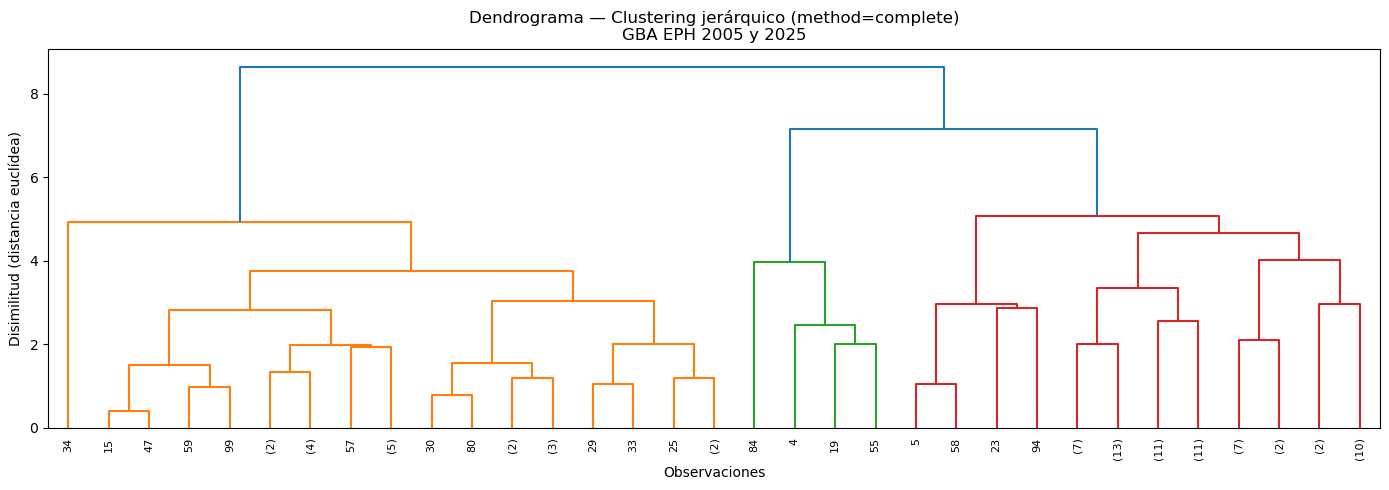

Distribución de observaciones por cluster (n=100):
0    67
1     4
2    29
Name: count, dtype: int64


In [26]:
# 1. Usamos las 6 variables estandarizadas del PCA 
# df_pca_std ya tiene las 6 variables limpias y estandarizadas
# Tomamos una muestra para que el dendrograma sea legible

np.random.seed(10)
muestra_idx = np.random.choice(len(df_pca_std), size=100, replace=False)
X_hclust = df_pca_std.iloc[muestra_idx].values

# Clustering jerárquico con linkage completo 
linkage_data = linkage(X_hclust, method='complete', metric='euclidean')

#  Dendrograma 
fig, ax = plt.subplots(figsize=(14, 5))

dendrogram(
    linkage_data,
    ax=ax,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    color_threshold=0.7 * max(linkage_data[:, 2])
)

ax.set_xlabel('Observaciones')
ax.set_ylabel('Disimilitud (distancia euclídea)')
ax.set_title('Dendrograma — Clustering jerárquico (method=complete)\nGBA EPH 2005 y 2025', fontsize=12)

plt.tight_layout()
plt.savefig('dendrograma.png', dpi=300, bbox_inches='tight')
plt.show()

# Corte en 3 clusters para ver composición 
labels_hclust = cut_tree(linkage_data, n_clusters=3).reshape(-1)
print("Distribución de observaciones por cluster (n=100):")
print(pd.Series(labels_hclust).value_counts().sort_index())

### Ejercicio 7 (optativo)

In [27]:
# Primero verificamos las variables dummy
# Buscamos columnas con pocos valores únicos 

resumen = pd.DataFrame({
    'n_unicos': df_eph_GBA.nunique(),
    'dtype': df_eph_GBA.dtypes,
    'ejemplo': df_eph_GBA.apply(lambda x: x.dropna().unique()[:4].tolist())
})


# Filtramos las que tienen entre 2 y 10 valores únicos (dummies y categóricas)

candidatas = resumen[(resumen['n_unicos'] >= 2) & (resumen['n_unicos'] <= 10)]
print(f"Columnas candidatas: {len(candidatas)}")
print(candidatas.to_string())

Columnas candidatas: 142
            n_unicos    dtype                            ejemplo
NRO_HOGAR          6  float64               [1.0, 2.0, 4.0, 3.0]
H15                3  float64                    [1.0, 0.0, 2.0]
ANO4               2    int64                       [2005, 2025]
AGLOMERADO         2  float64                       [32.0, 33.0]
CH03              10  float64               [1.0, 2.0, 3.0, 8.0]
CH04               2  float64                         [1.0, 2.0]
CH07               5  float64               [2.0, 5.0, 4.0, 1.0]
CH08               6  float64              [1.0, 4.0, 2.0, 12.0]
CH09               4  float64               [1.0, 3.0, 2.0, 9.0]
CH10               5  float64               [2.0, 1.0, 0.0, 3.0]
CH11               4  float64               [0.0, 2.0, 1.0, 9.0]
CH13               4  float64               [2.0, 1.0, 0.0, 9.0]
CH15               6  float64               [1.0, 3.0, 2.0, 4.0]
CH16               7  float64               [1.0, 6.0, 3.0, 4.0]


Nos da 142 dummies. Elegimos las más conceptualmente relevantes. Además, verificamos que no tengan muchos NaN.

In [31]:
# Variables con #NaN < 4000
vars_kmodes = [
    'CH04',     # sexo                      — 0 NaN
    'CH07',     # estado civil              — 5 NaN
    'CH08',     # cobertura médica          — 24 NaN
    'CH09',     # lugar de nacimiento       — 0 NaN
    'CH10',     # asiste a establecimiento  — 0 NaN
    'CH13',     # finalizó nivel educativo  — 0 NaN
    'CH15',     # residencia hace 5 años    — 0 NaN
    'NIVEL_ED', # nivel educativo           — 0 NaN
    'ESTADO',   # condición de actividad    — 0 NaN
    'CAT_OCUP', # categoría ocupacional     — 1 NaN
    'CAT_INAC', # categoría de inactividad  — 0 NaN
]

#Ver cuántos NaN tiene cada variable 
print("NaN por variable en df_eph_GBA:")
print(df_eph_GBA[vars_kmodes].isna().sum().sort_values(ascending=False))
print(f"\nFilas sin ningún NaN en las 22 variables: {df_eph_GBA[vars_kmodes].dropna().shape[0]}")

df_kmodes = (
    df_eph_GBA[vars_kmodes + ['informal']]
    .dropna(subset=vars_kmodes)
    .copy()
)



X_cat = df_kmodes[vars_kmodes].astype(str).values
print(f"Observaciones para k-modes: {len(df_kmodes)}")
print(f"Variables utilizadas: {len(vars_kmodes)}")


# K-modes con k=2, k=4, k=10 
resultados_km = {}
for k in [2, 4, 10]:
    km = KModes(n_clusters=k, init='Huang', n_init=5, random_state=42)
    labels = km.fit_predict(X_cat)
    resultados_km[k] = labels
    print(f"\nk={k} - Costo final: {km.cost_:.1f}")


#   ¿K=2 separa formales e informales? 
df_kmodes['cluster_k2'] = resultados_km[2]

print("\nCrosstab cluster k=2 vs formal/informal:")
print(pd.crosstab(
    df_kmodes['cluster_k2'],
    df_kmodes['informal'],
    rownames=['Cluster'],
    colnames=['Informal (0=Formal, 1=Informal)'],
    margins=True,
    normalize='index'
).round(3))

#  Centroides!
for k in [2, 4, 10]:
    km = KModes(n_clusters=k, init='Huang', n_init=5, random_state=42)
    km.fit_predict(X_cat)
    centroides = pd.DataFrame(km.cluster_centroids_, columns=vars_kmodes)
    print(f"\n Centroides (modas) k={k}")
    print(centroides[['CH04', 'NIVEL_ED', 'ESTADO', 'CAT_OCUP', 'CAT_INAC']].to_string())

NaN por variable en df_eph_GBA:
CH08        24
CH07         5
CAT_OCUP     1
CH04         0
CH09         0
CH10         0
CH13         0
CH15         0
NIVEL_ED     0
ESTADO       0
CAT_INAC     0
dtype: int64

Filas sin ningún NaN en las 22 variables: 16837
Observaciones para k-modes: 16837
Variables utilizadas: 11

k=2 - Costo final: 61131.0

k=4 - Costo final: 49022.0

k=10 - Costo final: 38140.0

Crosstab cluster k=2 vs formal/informal:
Informal (0=Formal, 1=Informal)    0.0    1.0
Cluster                                      
0                                0.699  0.301
1                                0.572  0.428
All                              0.694  0.306

 Centroides (modas) k=2
  CH04 NIVEL_ED ESTADO CAT_OCUP CAT_INAC
0  1.0      4.0    1.0      3.0      0.0
1  2.0      1.0    3.0      0.0      3.0

 Centroides (modas) k=4
  CH04 NIVEL_ED ESTADO CAT_OCUP CAT_INAC
0  1.0      4.0    1.0      3.0      0.0
1  1.0      1.0    3.0      0.0      3.0
2  2.0      5.0    1.0      3

Como la tabla no es muy interpretable, hacemos un código de barras para mostrarlo visualmente con gráficos de barras.

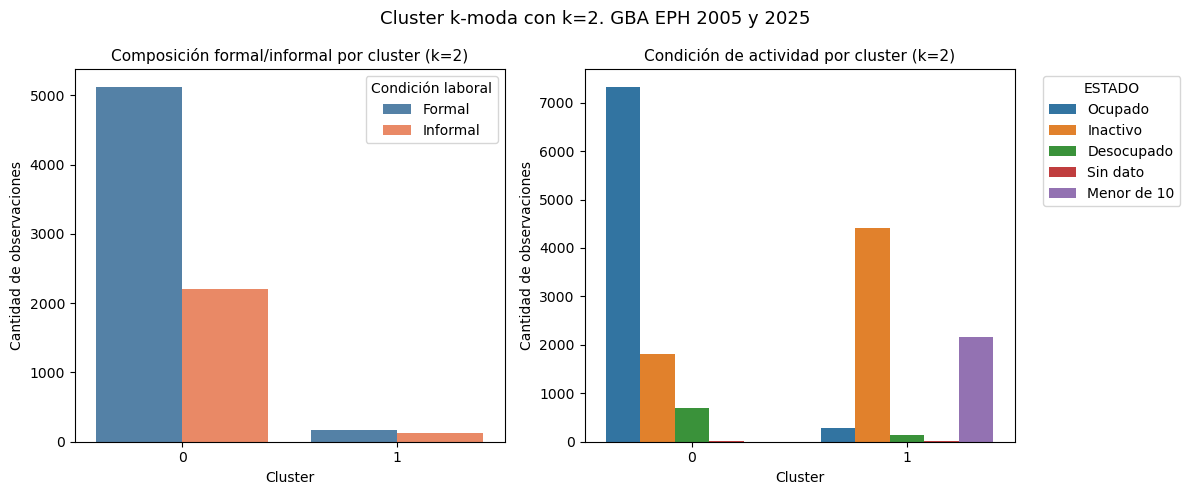

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# composición formal/informal por cluster 

df_kmodes['informal_label'] = df_kmodes['informal'].map({0.0: 'Formal', 1.0: 'Informal'})


sns.countplot(
    data=df_kmodes.dropna(subset=['informal_label']),
    x='cluster_k2',
    hue='informal_label',
    ax=axes[0],
    palette={'Formal': 'steelblue', 'Informal': 'coral'}
)


axes[0].set_title('Composición formal/informal por cluster (k=2)', fontsize=11)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Cantidad de observaciones')
axes[0].legend(title='Condición laboral')



# composición por ESTADO (condición de actividad) 
estado_labels = {
    1.0: 'Ocupado',
    2.0: 'Desocupado',
    3.0: 'Inactivo',
    4.0: 'Menor de 10',
    0.0: 'Sin dato'
}



df_kmodes['estado_label'] = df_kmodes['ESTADO'].map(estado_labels)



sns.countplot(
    data=df_kmodes,
    x='cluster_k2',
    hue='estado_label',
    ax=axes[1],
    palette='tab10'
)


axes[1].set_title('Condición de actividad por cluster (k=2)', fontsize=11)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Cantidad de observaciones')
axes[1].legend(title='ESTADO', bbox_to_anchor=(1.05, 1), loc='upper left')


plt.suptitle('Cluster k-moda con k=2. GBA EPH 2005 y 2025', fontsize=13)
plt.tight_layout()
plt.savefig('kmodes_k2.png', dpi=300, bbox_inches='tight')
plt.show()

# Parte III: Herramientas de IA y reflexión final


Realizado en documento de LaTeX. 